In [ ]:
# SCOPE OF DATA ENGINEERING
# ANALYSING THE DATA THROUGH VISUALIZATION
# ETL OF DATA LOADED
# API FETCHING AND HANDLING THE COLLECTED DATA
# BIG DATA ANALYTICS USING PYSPARK
# ML LERANING USING LLM FOR THE OUTPUT PREDICTION
# GENERATTIVE AI
# EMBEDDINGS AND
# RAG - RETRIEVAL AUGUMENTED GENERATION
# AGENTIC AI
# CAPSTONE

In [ ]:
# EXISTING DATA ENGINEERING

# AI - FIRST PIPELINES
# REAL - TIME STREAMING
# VECTOR + RELATIONAL
# DATAOPS + MLOPS


In [ ]:
# ACCURACY - PRECISE OUTPUT
# FAIRNESS - SAY TRUTH
# PRIVACY - END TO END ENCRYPTION
# TRANSPARENCY - IT WILL MAKE THE DATA RETRIEVAL ONLY NECESSSARY RESOURCES


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Summer_Internship_2026/student_performance.csv")
print("=== Data Loaded Successfully ===")

=== Data Loaded Successfully ===


In [ ]:
df.head(5)

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [ ]:
print(df.columns)

Index(['student_id', 'name', 'age', 'gender', 'department', 'semester',
       'math_score', 'science_score', 'english_score', 'programming_score',
       'attendance_percentage', 'city', 'admission_year'],
      dtype='object')


In [ ]:
print(f"DataSet Contains {df.shape[0]} Rows and {df.shape[1]} Columns")

DataSet Contains 30 Rows and 13 Columns


In [ ]:
print(df.dtypes)

student_id                int64
name                     object
age                       int64
gender                   object
department               object
semester                  int64
math_score                int64
science_score             int64
english_score             int64
programming_score         int64
attendance_percentage     int64
city                     object
admission_year            int64
dtype: object


In [ ]:
import sqlite3
conn = sqlite3.connect("Placement.db")
cursor = conn.cursor()
df.to_sql(
    "Placement",
    conn,
    if_exists="replace",
    index=False
)

30

In [ ]:
query = input("ENTER THE QUERY : ")
df = pd.read_sql(query,conn)
print("EXECUTING THE QUERY....")
print("\n",df)

ENTER THE QUERY : SELECT * FROM Placement;
EXECUTING THE QUERY....

     student_id            name  age  gender        department  semester  \
0         1001    Aarav Sharma   19    Male  Computer Science         2   
1         1002     Priya Patel   20  Female  Computer Science         2   
2         1003     Rohit Verma   19    Male       Electronics         2   
3         1004     Sneha Reddy   20  Female        Mechanical         2   
4         1005      Arjun Nair   19    Male  Computer Science         2   
5         1006     Meera Joshi   20  Female       Electronics         2   
6         1007     Kiran Kumar   21    Male             Civil         2   
7         1008     Divya Singh   19  Female  Computer Science         2   
8         1009    Rahul Mishra   20    Male        Mechanical         2   
9         1010      Ananya Das   19  Female  Computer Science         2   
10        1011     Vikram Iyer   20    Male       Electronics         2   
11        1012     Pooja Gupta 

In [ ]:
query = input("ENTER THE QUERY : ")
def run_query(query,db_name = "Placement.db"):
  conn = sqlite3.connect(db_name)
  data = pd.read_sql(query,conn)
  conn.close()
  return data
print("\nEXECUTING QUERY .....")
print(run_query(query))

ENTER THE QUERY : SELECT * FROM Placement;

EXECUTING QUERY .....
    student_id            name  age  gender        department  semester  \
0         1001    Aarav Sharma   19    Male  Computer Science         2   
1         1002     Priya Patel   20  Female  Computer Science         2   
2         1003     Rohit Verma   19    Male       Electronics         2   
3         1004     Sneha Reddy   20  Female        Mechanical         2   
4         1005      Arjun Nair   19    Male  Computer Science         2   
5         1006     Meera Joshi   20  Female       Electronics         2   
6         1007     Kiran Kumar   21    Male             Civil         2   
7         1008     Divya Singh   19  Female  Computer Science         2   
8         1009    Rahul Mishra   20    Male        Mechanical         2   
9         1010      Ananya Das   19  Female  Computer Science         2   
10        1011     Vikram Iyer   20    Male       Electronics         2   
11        1012     Pooja Gupta   1

In [ ]:
import matplotlib.pyplot as plt

conn = sqlite3.connect("Placement.db")
cursor = conn.cursor()
chart_sql = """SELECT department , ROUND(AVG(math_score)) AS avg_math
              FROM Placement
              GROUP BY department
              ORDER BY avg_math DESC"""
data = pd.read_sql(chart_sql,conn)
print("\nEXECUTING QUERY .....")
print(data)



EXECUTING QUERY .....
         department  avg_math
0  Computer Science      86.0
1        Mechanical      71.0
2       Electronics      71.0
3             Civil      63.0


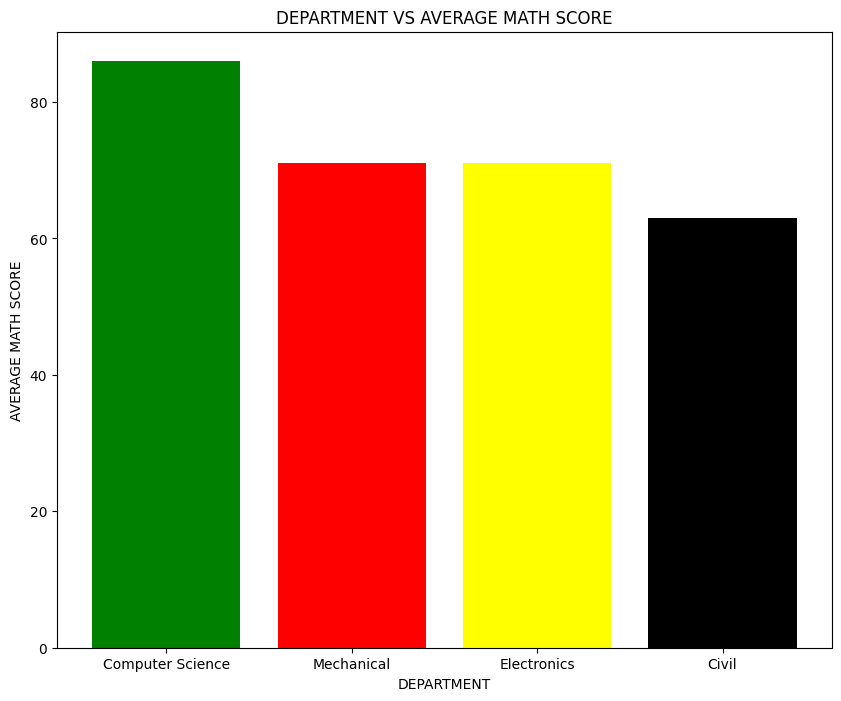

In [ ]:
import matplotlib.pyplot as plt
fig , ax = plt.subplots(figsize=(10,8))
plt.xlabel("DEPARTMENT")
plt.ylabel("AVERAGE MATH SCORE")
plt.title("DEPARTMENT VS AVERAGE MATH SCORE")
plt.bar(data['department'],data['avg_math'],color=['green','red','yellow','black'])
plt.show()

In [ ]:
print("=== NUMBER OF MISSING VALUES ===")
print(df.isnull().sum())

=== NUMBER OF MISSING VALUES ===
student_id               0
name                     0
age                      0
gender                   0
department               0
semester                 0
math_score               0
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64


In [ ]:
import numpy as np

df.loc[2, 'math_score'] = np.nan
df.loc[5, 'age'] = np.nan
df.loc[8, 'department'] = np.nan
print(df.isnull().sum())

student_id               0
name                     0
age                      1
gender                   0
department               1
semester                 0
math_score               1
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64


In [ ]:
print("Total Number of Missing Values : ",df.isnull().sum().sum())

Total Number of Missing Values :  3


In [20]:
API_KEY = "a59a2f8ba2d8c17e32d31372c1e430de"

In [19]:
BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'

In [ ]:
Cities = ['Mumbai','Delhi','Bangalore','Chennai','Hyderabad','Kolkata','Pune','Jaipur','coimbatore']

In [ ]:
import requests
def fetch_weather(city, api_key):
  params={
      'q':city,
      'appid':api_key,
      'units':'metric'
  }

  try:
    response=requests.get(BASE_URL,params=params,timeout=10)

    if response.status_code==200:
      data=response.json()

      return{
          'city': city,
          'temperature':round(data['main']['temp'],1),
          'description':data['weather'][0]['description'],
          'humidity':data['main']['humidity'],
          'wind_speed':data['wind']['speed'],
          'pressure': data['main']['pressure'],
          'condition':data['weather'][0]['description'].title(),
          'visibility':data.get('visibility',0)//1000
      }
    else:
      print(f'Error {response.status_code} for {city}: {response.json().get("message","Unknown Error")}')
      return None
  except requests.exceptions.ConnectionError:
    print('Connection Error')
    return None
  except requests.exceptions.Timeout:
    print('Request Timeout')

In [ ]:
import pandas as pd

chennai_input = fetch_weather(Cities[3],API_KEY)
print("Fetching weather data for all cities...")
print("")
if chennai_input:
  print(chennai_input)
else:
  print("Failed to fetch weather data for Chennai.")
pdf = pd.DataFrame([chennai_input])
print(pdf)

Fetching weather data for all cities...

{'city': 'Chennai', 'temperature': 35.7, 'description': 'overcast clouds', 'humidity': 50, 'wind_speed': 2.24, 'pressure': 1006, 'condition': 'Overcast Clouds', 'visibility': 10}
      city  temperature      description  humidity  wind_speed  pressure  \
0  Chennai         35.7  overcast clouds        50        2.24      1006   

         condition  visibility  
0  Overcast Clouds          10  


In [ ]:
import pandas as pd

print("Fetching weather data for all cities...")
print("")

all_cities_weather_data = []
for city_name in Cities:
  city_weather = fetch_weather(city_name, API_KEY)
  if city_weather:
    all_cities_weather_data.append(city_weather)
  else:
    print(f'Could not fetch weather data for {city_name}')

print("")
print("-"*80)

if all_cities_weather_data:
  pdf = pd.DataFrame(all_cities_weather_data)
  print(pdf)
else:
  print("No weather data was successfully fetched for any city.")

Fetching weather data for all cities...


--------------------------------------------------------------------------------
        city  temperature      description  humidity  wind_speed  pressure  \
0     Mumbai         31.1        clear sky        71        4.60      1007   
1      Delhi         35.6  overcast clouds        31        2.33      1003   
2  Bangalore         27.9  overcast clouds        64       18.33      1011   
3    Chennai         36.1  overcast clouds        49        2.68      1006   
4  Hyderabad         31.8    broken clouds        45        4.68      1007   
5    Kolkata         38.4    broken clouds        40        1.44      1002   
6       Pune         32.5       few clouds        40        4.26      1008   
7     Jaipur         33.8       few clouds        42        4.15      1004   

         condition  visibility  
0        Clear Sky          10  
1  Overcast Clouds          10  
2  Overcast Clouds          10  
3  Overcast Clouds          10  
4    Brok

In [ ]:
print("Fetching the Weather API ....")
coimbatore_city = fetch_weather(Cities[8],API_KEY)
if coimbatore_city:
  print(coimbatore_city)
else:
  print("Failed to fetch weather data for Coimbatore.")
pdf = pd.DataFrame([coimbatore_city])
print(pdf)

Fetching the Weather API ....
{'city': 'coimbatore', 'temperature': 27.6, 'description': 'overcast clouds', 'humidity': 64, 'wind_speed': 6.45, 'pressure': 1011, 'condition': 'Overcast Clouds', 'visibility': 10}
         city  temperature      description  humidity  wind_speed  pressure  \
0  coimbatore         27.6  overcast clouds        64        6.45      1011   

         condition  visibility  
0  Overcast Clouds          10  


ENTER THE CITY : Coimbatore
Fetching the Weather API ....
{'city': 'Coimbatore', 'temperature': 30.5, 'description': 'overcast clouds', 'humidity': 52, 'wind_speed': 8.25, 'pressure': 1007, 'condition': 'Overcast Clouds', 'visibility': 10}
         city  temperature      description  humidity  wind_speed  pressure  \
0  Coimbatore         30.5  overcast clouds        52        8.25      1007   

         condition  visibility  
0  Overcast Clouds          10  


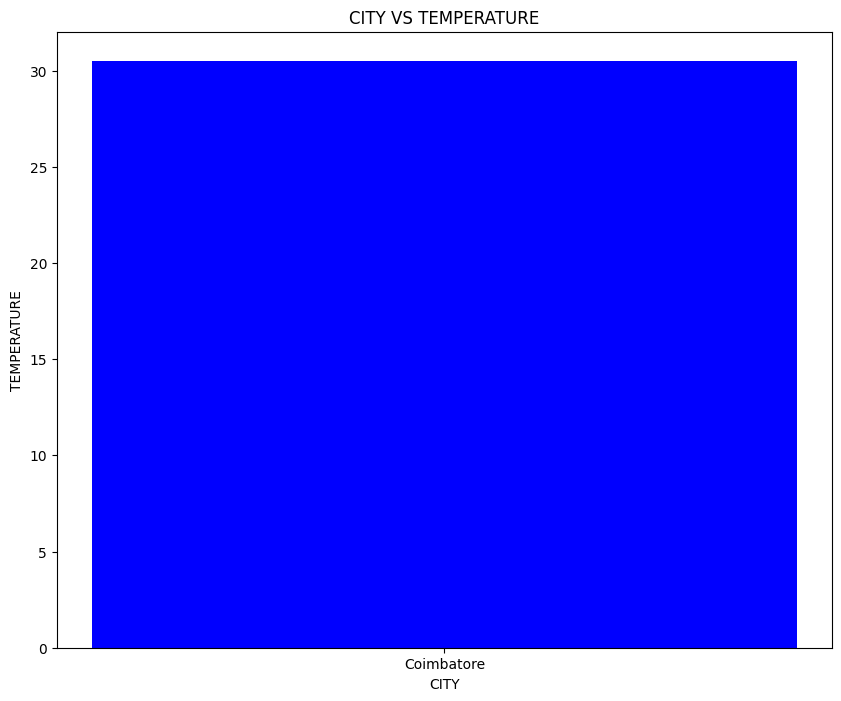

In [22]:
import matplotlib.pyplot as plt
import requests
place = input("ENTER THE CITY : ")
def fetch_weather(place, api_key):
  params={
      'q':place,
      'appid':api_key,
      'units':'metric'
  }

  try:
    response=requests.get(BASE_URL,params=params,timeout=10)

    if response.status_code==200:
      data=response.json()

      return{
          'city': place,
          'temperature':round(data['main']['temp'],1),
          'description':data['weather'][0]['description'],
          'humidity':data['main']['humidity'],
          'wind_speed':data['wind']['speed'],
          'pressure': data['main']['pressure'],
          'condition':data['weather'][0]['description'].title(),
          'visibility':data.get('visibility',0)//1000
      }
    else:
      print(f'Error {response.status_code} for {place}: {response.json().get("message","Unknown Error")}')
      return None
  except requests.exceptions.ConnectionError:
    print('Connection Error')
    return None
  except requests.exceptions.Timeout:
    print('Request Timeout')
print("Fetching the Weather API ....")
city_weather = fetch_weather(place, API_KEY)
if city_weather:
  print(city_weather)
else:
  print("Failed to fetch weather data for a City")
pdf = pd.DataFrame([city_weather])
print(pdf)
fig , ax = plt.subplots(figsize=(10,8))
plt.xlabel("CITY")
plt.ylabel("TEMPERATURE")
plt.title("CITY VS TEMPERATURE")
plt.bar(pdf['city'],pdf['temperature'],color=['blue'])
plt.show()

In [ ]:
place = input("ENTER THE CITY : ")
def fetch_weather(place, api_key):
  params={
      'q':place,
      'appid':api_key,
      'units':'metric'
  }

  try:
    response=requests.get(BASE_URL,params=params,timeout=10)

    if response.status_code==200:
      data=response.json()

      return{
          'city': place,
          'temperature':round(data['main']['temp'],1),
          'description':data['weather'][0]['description'],
          'humidity':data['main']['humidity'],
          'wind_speed':data['wind']['speed'],
          'pressure': data['main']['pressure'],
          'condition':data['weather'][0]['description'].title(),
          'visibility':data.get('visibility',0)//1000
      }
    else:
      print(f'Error {response.status_code} for {place}: {response.json().get("message","Unknown Error")}')
      return None
  except requests.exceptions.ConnectionError:
    print('Connection Error')
    return None
  except requests.exceptions.Timeout:
    print('Request Timeout')
print("Fetching the Weather API ....")
city_weather = fetch_weather(place, API_KEY)
if city_weather:
  print(city_weather)
else:
  print("Failed to fetch weather data for a City")
pdf = pd.DataFrame([city_weather])
print(pdf)

ENTER THE CITY : coimbatore
Fetching the Weather API ....
{'city': 'coimbatore', 'temperature': 27.6, 'description': 'overcast clouds', 'humidity': 64, 'wind_speed': 6.45, 'pressure': 1011, 'condition': 'Overcast Clouds', 'visibility': 10}
         city  temperature      description  humidity  wind_speed  pressure  \
0  coimbatore         27.6  overcast clouds        64        6.45      1011   

         condition  visibility  
0  Overcast Clouds          10  


In [ ]:
# AI BIAS - UNFAIR ERROR
# BASED ON PHOTO EVEN NOT RECOGNIZE THE OUTPUT IS AI BIAS
# TRAINING DATA REFLECTS THE HUMAN ERROR WHERE IT ALREADY EXIST
# PREDICTS WRONGLY BASED ON THE TRAINNING DATASETS
# MULTI - FACTOR AUTHENTICATION
# 2FA - TWO FACTOR AUTHENTICATION

In [ ]:
! pip install pyspark -q
print("PYSPARK INSTALLES SUCCESSFULLY")

PYSPARK INSTALLES SUCCESSFULLY


In [ ]:
# Create Spark Session

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("StudentPerformance") \
    .getOrCreate()

In [ ]:
bronze_df = spark.read.csv(
    '/content/drive/MyDrive/Summer_Internship_2026/student_performance.csv',
    header=True,
    inferSchema=True
)

In [ ]:
print("===== First Five Rows =====")
print()
bronze_df.show(5, truncate=False)

print()

print("===== Last Five Rows =====")
print()
last = bronze_df.tail(5)
spark.createDataFrame(last, bronze_df.schema).show(truncate=False)

===== First Five Rows =====

+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|student_id|name        |age|gender|department      |semester|math_score|science_score|english_score|programming_score|attendance_percentage|city     |admission_year|
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|1001      |Aarav Sharma|19 |Male  |Computer Science|2       |85        |78           |72           |91               |92                   |Mumbai   |2023          |
|1002      |Priya Patel |20 |Female|Computer Science|2       |76        |82           |88           |79               |87                   |Ahmedabad|2023          |
|1003      |Rohit Verma |19 |Male  |Electronics     |2       |65        |74           |61           |55               |78               

In [ ]:
# DATA ENGINEERING -> PYTHON -> PYSPARK -> BASIC LIBRARY -> PROJECT PIPELINE -> CLOUD MANAGEMENT

In [1]:
# DEVOPS ENGINEER
# NETWORKING - (LAN , WAN , PAN , MAN) -> LINUX (TIME DURATION 1 WEEK)
# CLOUD PLATFORM - AWS , GCP , AZURE (20+ SERVICES)
# DEVOPS TOOLS
# GIT & GITHUB
# JENKINS - AUTOMATION TO DEPLOYMENT
# GIT ACTIONS FOR LARGE YML FILE FOR RUNNING PROJECT WORKFLOW MANAGEMENT
# DOCKER
# ML ENGINEER
# STATISTICS
# MACHINE LEARNING PACKAGES AND LIBRARIES
# DEEP LEARNING
# NATURAL LANGUAGE PROCESSING (NLP)
# LLM's LARGE LANGUAGE MODELS
# MLOPS - MACHINE LEARNING + OPERATING SYSTEM
print("Future placement")

Future placement


In [3]:
!pip install groq pandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 1.4 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import os
import sqlite3
from groq import Groq
import re

In [5]:
import os
os.environ["GROQ_API_KEY"] = "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"
client = Groq(api_key=os.environ["GROQ_API_KEY"])
MODEL = "llama-3.1-8b-instant"
print("Using Model : ",MODEL)


Using Model :  llama-3.1-8b-instant


In [6]:
import io
df = pd.read_csv("/content/drive/MyDrive/Summer_Internship_2026/student_performance.csv")
print("=== Data Loaded Successfully ===")
print("-"*40)
df.head(5)

=== Data Loaded Successfully ===
----------------------------------------


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("All Libraries Imported Sucessfully !!!!")

All Libraries Imported Sucessfully !!!!


In [8]:
print("=== GENDER ENCODING ===")
df_ml = df.copy()
le_gender = LabelEncoder()
df_ml['gender'] = le_gender.fit_transform(df_ml['gender'])
print(f"Gender encoding : {dict(zip(le_gender.classes_,le_gender.transform(le_gender.classes_)))}")

=== GENDER ENCODING ===
Gender encoding : {'Female': np.int64(0), 'Male': np.int64(1)}


In [9]:
print("=== DEPARTMENT ENCODING ===")
le_dept = LabelEncoder()
df_ml['department'] = le_dept.fit_transform(df_ml['department'])
print(f"Department Encoding : {dict(zip(le_dept.classes_,le_dept.transform(le_dept.classes_)))}")

=== DEPARTMENT ENCODING ===
Department Encoding : {'Civil': np.int64(0), 'Computer Science': np.int64(1), 'Electronics': np.int64(2), 'Mechanical': np.int64(3)}


In [10]:
print("=== SEMESTER ENCODING ===")
le_sem = LabelEncoder()
df_ml['semester'] = le_sem.fit_transform(df_ml['semester'])
print(f"Semester Encoding : {dict(zip(le_sem.classes_,le_sem.transform(le_sem.classes_)))}")

=== SEMESTER ENCODING ===
Semester Encoding : {np.int64(2): np.int64(0)}


In [11]:
feature_col = [
    'math_score',
    'science_score',
    'attendance_percentage',
    'gender',
    'department'
]
x = df_ml[feature_col]
y = df_ml['programming_score']
print("Feature Matrix X shape : ",x.shape)
print("Target Vector Y shape : ",y.shape)
print(f"Target Range from  {y.min()} to {y.max()} mean : {y.mean():.1f}")

Feature Matrix X shape :  (30, 5)
Target Vector Y shape :  (30,)
Target Range from  38 to 97 mean : 67.6


In [12]:
X_train , X_test ,Y_train , Y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)
print(f"Total Students : {len(x)}")
print(f"Training Students : {len(X_train)} : ({len(X_train)/len(x)*100:.0f}) %")
print(f"Testing Students : {len(X_test)} ({len(X_test)/len(x)*100:.0f})")
print(f"Traininf target Range {Y_train.min()} to {Y_train.max()} mean : {Y_train.mean():.1f}")
print(f"Testing target Range {Y_test.min()} to {Y_test.max()} mean : {Y_test.mean():.1f}")

Total Students : 30
Training Students : 24 : (80) %
Testing Students : 6 (20)
Traininf target Range 38 to 96 mean : 68.0
Testing target Range 39 to 97 mean : 65.8


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
print("=== Features Scaled Sucessfully ===")
X_test_scaled =  scaler.transform(X_test)
print(f"Training feature mean (should be 0 ) : {X_train_scaled.mean():.4f}")
print("Traing feature Std (should be -1 ) : ",X_train_scaled.std())

=== Features Scaled Sucessfully ===
Training feature mean (should be 0 ) : 0.0000
Traing feature Std (should be -1 ) :  1.0


In [16]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled,Y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_mae = mean_absolute_error(Y_test,lr_pred)
lr_mse = np.sqrt(mean_squared_error(Y_test,lr_pred))
lr_r2 = r2_score(Y_test,lr_pred)
lr_rmse = np.sqrt(lr_mse)

print("=== MODEL IN LINEAR REGRESSION AND ML PREDICTION ===")
print(f"MAE : {lr_mae:.2f}")
print(f"MSE : {lr_mse:.2f}")
print(f"R2 : {lr_r2:.4f}")
print(f"RMSE : {lr_rmse:.2f}")
results = pd.DataFrame({
    "Actual_Score": Y_test.values,
    "Predicted_Score": lr_pred
})

=== MODEL IN LINEAR REGRESSION AND ML PREDICTION ===
MAE : 9.84
MSE : 11.88
R2 : 0.7164
RMSE : 3.45


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, Y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)

# Metrics
lr_mae = mean_absolute_error(Y_test, lr_pred)
lr_mse = mean_squared_error(Y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(Y_test, lr_pred)

print("=== LINEAR REGRESSION MODEL PERFORMANCE ===")
print(f"MAE  : {lr_mae:.2f}")
print(f"MSE  : {lr_mse:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R²   : {lr_r2:.4f}")

# Create results DataFrame
results = pd.DataFrame({
    "Actual_Score": Y_test.values,
    "Predicted_Score": lr_pred
})

print("\n=== PREDICTIONS WITH NATURAL LANGUAGE ===")

for i, row in results.head(10).iterrows():   # change 10 to len(results) for all rows
    print(
        f"Student {i+1}: "
        f"Predicted Score = {row['Predicted_Score']:.1f}, "
        f"Actual Score = {row['Actual_Score']:.1f}. "
        f"The model predicts that this student is expected to score "
        f"approximately {row['Predicted_Score']:.1f} marks."
    )

=== LINEAR REGRESSION MODEL PERFORMANCE ===
MAE  : 9.84
MSE  : 141.09
RMSE : 11.88
R²   : 0.7164

=== PREDICTIONS WITH NATURAL LANGUAGE ===
Student 1: Predicted Score = 44.0, Actual Score = 39.0. The model predicts that this student is expected to score approximately 44.0 marks.
Student 2: Predicted Score = 85.4, Actual Score = 69.0. The model predicts that this student is expected to score approximately 85.4 marks.
Student 3: Predicted Score = 73.1, Actual Score = 53.0. The model predicts that this student is expected to score approximately 73.1 marks.
Student 4: Predicted Score = 94.5, Actual Score = 92.0. The model predicts that this student is expected to score approximately 94.5 marks.
Student 5: Predicted Score = 56.3, Actual Score = 45.0. The model predicts that this student is expected to score approximately 56.3 marks.
Student 6: Predicted Score = 100.7, Actual Score = 97.0. The model predicts that this student is expected to score approximately 100.7 marks.
